# M5 Forecasting — LightGBM 

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import mean_squared_error
import gc
import warnings
warnings.filterwarnings("ignore")

### Carga de datos

In [2]:
train = pd.read_parquet('m5_train.parquet')
val   = pd.read_parquet('m5_val.parquet')
print(f"Train: {train.shape} | Val: {val.shape}")

# Filtrar últimos ~2 años para aliviar RAM
#train = train[train['d_num'] > 900].reset_index(drop=True)
#print(f"Train filtrado: {train.shape}")


Train: (58327370, 27) | Val: (853720, 27)


### Features + encode categóricas

In [3]:
CAT_FEATURES = ['item_id', 'dept_id', 'cat_id', 'store_id',
                'state_id', 'event_name_1', 'event_type_1']

NUM_FEATURES = ['d_num', 'wday', 'month', 'year', 'sell_price', 'snap',
                'lag_7', 'lag_21', 'lag_28', 'lag_60',
                'ma_7',  'ma_21',  'ma_28',  'ma_60',
                'std_7', 'std_28']

FEATURES = CAT_FEATURES + NUM_FEATURES
TARGET   = 'ventas'

train = train.dropna(subset=NUM_FEATURES).reset_index(drop=True)
val   = val.dropna(subset=NUM_FEATURES).reset_index(drop=True)

for col in CAT_FEATURES:
    train[col] = train[col].astype('category').cat.codes.astype('int16')
    val[col]   = val[col].astype('category').cat.codes.astype('int16')

X_train, y_train = train[FEATURES], train[TARGET].astype('float32')
X_val,   y_val   = val[FEATURES],   val[TARGET].astype('float32')
cat_indices      = [FEATURES.index(c) for c in CAT_FEATURES]

# Guardar item_id y sell_price originales para WRMSSE antes de borrar train
wrmsse_val = val[['item_id', 'store_id', 'd_num', 'ventas', 'sell_price']].copy()
wrmsse_train_ventas = train[['item_id', 'store_id', 'ventas']].copy()

del train
gc.collect()
print(f"X_train: {X_train.shape} | X_val: {X_val.shape}")


X_train: (45258166, 23) | X_val: (853720, 23)


### Dataset LIGHTGBM

In [4]:
print("Creando datasets LightGBM ...")

lgb_train = lgb.Dataset(
    X_train, label=y_train,
    categorical_feature=cat_indices,
    free_raw_data=False
)

lgb_val = lgb.Dataset(
    X_val, label=y_val,
    categorical_feature=cat_indices,
    reference=lgb_train,
    free_raw_data=False
)

del X_train, y_train
gc.collect()


Creando datasets LightGBM ...


0

### Hiperparámetros

In [5]:
params = {
    'objective':               'tweedie',
    'tweedie_variance_power':  1.1,
    'metric':                  'rmse',
    'boosting_type':           'gbdt',
    'num_leaves':              127,
    'max_depth':               -1,
    'learning_rate':           0.05,
    'feature_fraction':        0.8,
    'bagging_fraction':        0.8,
    'bagging_freq':            1,
    'min_child_samples':       20,
    'lambda_l1':               0.1,
    'lambda_l2':               0.1,
    'n_jobs':                  -1,
    'seed':                    42,
    'verbose':                 -1,
}


### Entrenamiento

In [6]:
print("Entrenando modelo ...")

evals_result = {}   # ← aquí se almacena el historial de métricas

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=50),
    lgb.record_evaluation(evals_result),   # ← captura RMSE por iteración
]

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'val'],
    callbacks=callbacks,
)

print(f"\nMejor iteración: {model.best_iteration}")
print(f"Mejor RMSE val:  {model.best_score['val']['rmse']:.4f}")


Entrenando modelo ...
Training until validation scores don't improve for 50 rounds
[50]	train's rmse: 2.36121	val's rmse: 2.07504
[100]	train's rmse: 2.29743	val's rmse: 2.06148
Early stopping, best iteration is:
[71]	train's rmse: 2.31834	val's rmse: 2.05908

Mejor iteración: 71
Mejor RMSE val:  2.0591


### Curvas de aprendizaje

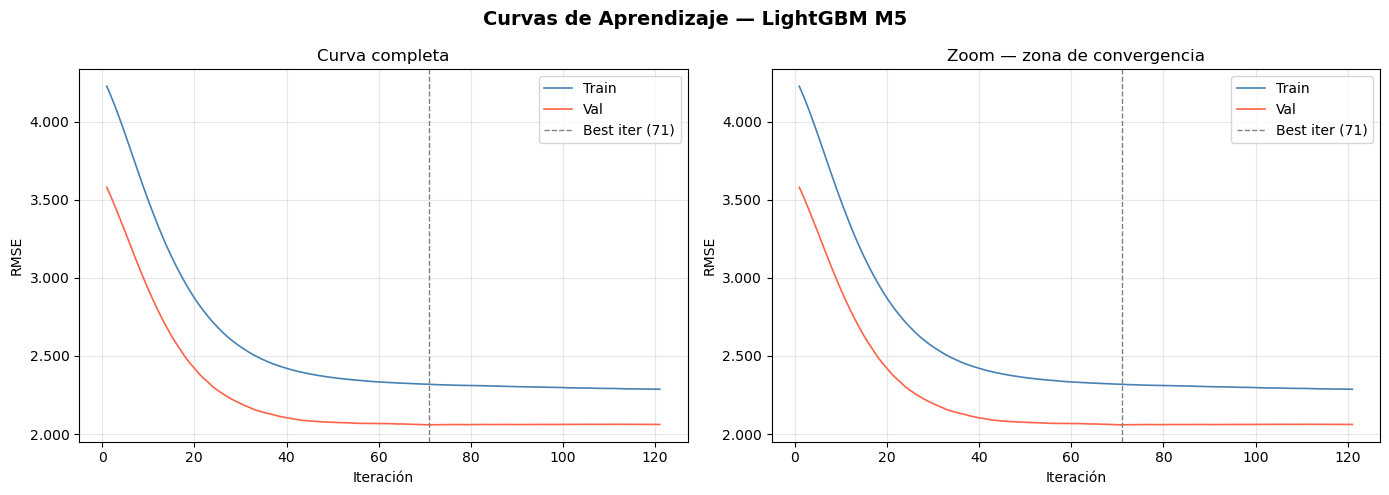

Curvas guardadas en learning_curves.png


In [7]:
train_rmse = evals_result['train']['rmse']
val_rmse   = evals_result['val']['rmse']
iterations = range(1, len(train_rmse) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Aprendizaje — LightGBM M5', fontsize=14, fontweight='bold')

# — Izquierda: curva completa
ax = axes[0]
ax.plot(iterations, train_rmse, label='Train', color='steelblue', linewidth=1.2)
ax.plot(iterations, val_rmse,   label='Val',   color='tomato',    linewidth=1.2)
ax.axvline(model.best_iteration, color='gray', linestyle='--', linewidth=1,
           label=f'Best iter ({model.best_iteration})')
ax.set_xlabel('Iteración')
ax.set_ylabel('RMSE')
ax.set_title('Curva completa')
ax.legend()
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

# — Derecha: zoom en las últimas 200 iteraciones
ax2 = axes[1]
zoom_start = max(0, model.best_iteration - 100)
ax2.plot(list(iterations)[zoom_start:], train_rmse[zoom_start:],
         label='Train', color='steelblue', linewidth=1.2)
ax2.plot(list(iterations)[zoom_start:], val_rmse[zoom_start:],
         label='Val',   color='tomato',    linewidth=1.2)
ax2.axvline(model.best_iteration, color='gray', linestyle='--', linewidth=1,
            label=f'Best iter ({model.best_iteration})')
ax2.set_xlabel('Iteración')
ax2.set_ylabel('RMSE')
ax2.set_title('Zoom — zona de convergencia')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Curvas guardadas en learning_curves.png")


### Evaluacion

In [8]:
preds = np.clip(model.predict(X_val, num_iteration=model.best_iteration), 0, None)

rmse = np.sqrt(mean_squared_error(y_val, preds))
mae  = np.mean(np.abs(y_val - preds))
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

# ── WRMSSE corregido ─────────────────────────────────────────
wrmsse_val = val[['item_id', 'store_id', 'd_num', 'ventas', 'sell_price']].copy()
wrmsse_val['pred'] = preds

# Escala por serie: RMSE del naive en train (shift 1)
# Se usa mean(ventas) como fallback si la serie tiene varianza 0
scale = (
    wrmsse_train_ventas
    .sort_values(['item_id', 'store_id'])
    .groupby(['item_id', 'store_id'])['ventas']
    .apply(lambda x: (
        np.sqrt(np.mean(np.diff(x.values) ** 2))
        if len(x) > 1 and np.std(x.values) > 0
        else x.mean()           # ← fallback: serie plana → usar media
    ))
    .reset_index()
    .rename(columns={'ventas': 'escala'})
)
# Evitar escalas cero o muy pequeñas
scale['escala'] = scale['escala'].clip(lower=0.5)

# RMSE por serie en val
rmse_serie = (
    wrmsse_val
    .groupby(['item_id', 'store_id'])
    .apply(lambda g: np.sqrt(mean_squared_error(g['ventas'], g['pred'])))
    .reset_index()
    .rename(columns={0: 'rmse_serie'})
)

# Peso por serie: revenue acumulado en val
peso_serie = (
    wrmsse_val
    .assign(revenue=lambda d: d['ventas'] * d['sell_price'].fillna(0))
    .groupby(['item_id', 'store_id'])['revenue']
    .sum()
    .reset_index()
    .rename(columns={'revenue': 'peso_raw'})
)
total_revenue = peso_serie['peso_raw'].sum()
peso_serie['peso'] = peso_serie['peso_raw'] / total_revenue

# Unir y calcular
wrmsse_df = rmse_serie.merge(scale,    on=['item_id', 'store_id'])
wrmsse_df = wrmsse_df.merge(peso_serie[['item_id', 'store_id', 'peso']], on=['item_id', 'store_id'])
wrmsse_df['rmsse'] = wrmsse_df['rmse_serie'] / wrmsse_df['escala']
wrmsse_df['wrmsse_contrib'] = wrmsse_df['peso'] * wrmsse_df['rmsse']

wrmsse = wrmsse_df['wrmsse_contrib'].sum()

print(f"WRMSSE: {wrmsse:.4f}")
print(f"\nDistribución RMSSE por serie:")
print(wrmsse_df['rmsse'].describe().round(3))
print(f"\nSeries con RMSSE > 10 (problemáticas): {(wrmsse_df['rmsse'] > 10).sum()}")
print(f"Series con peso > 0.001:               {(wrmsse_df['peso'] > 0.001).sum()}")


RMSE: 2.0591
MAE:  1.0125
WRMSSE: 0.8844

Distribución RMSSE por serie:
count    30487.000
mean         0.739
std          0.323
min          0.009
25%          0.550
50%          0.698
75%          0.877
max         10.490
Name: rmsse, dtype: float64

Series con RMSSE > 10 (problemáticas): 1
Series con peso > 0.001:               17


### Importancia de Features

### Gardar Modelo y predicciones

In [10]:
model.save_model('lgbm_m5.txt')
print("Modelo guardado: lgbm_m5.txt")

val['pred_ventas'] = preds
val[['item_id', 'store_id', 'd_num', 'ventas', 'pred_ventas']].to_csv(
    'm5_val_predictions.csv', index=False
)
print("Predicciones guardadas: m5_val_predictions.csv")


Modelo guardado: lgbm_m5.txt
Predicciones guardadas: m5_val_predictions.csv
